## Analisis Evaluasi Chatbot (BERTScore)

Notebook ini memuat analisis sederhana dari file CSV hasil evaluasi chatbot menggunakan metrik **BERTScore** (Precision, Recall, F1).

In [4]:
import pandas as pd

# Path file CSV (sesuaikan jika perlu)
csv_path = r"hasil_evaluasi_chatbot.csv"

df = pd.read_csv(csv_path)
df.head()

,Pertanyaan,Jawaban Chatbot,Referensi,Precision,Recall,F1 Score
0,Apa Visi Disdukcapil Kepulauan Anambas?,Halo! Visi Disdukcapil Kepulauan Anambas adala...,Terciptanya masyarakat sadar akan tertib admin...,0.988699,0.997657,0.993158
1,Dimana alamat Disdukcapil Kepulauan Anambas?,Halo! Kantor Disdukcapil Kepulauan Anambas ber...,"jl. imam bonjol no. 50, tarempa, kecamatan sia...",0.980615,0.988196,0.984391
2,Apakah ada biaya yang harus dibayarkan untuk m...,"Halo! Untuk pengurusan dokumen kependudukan, k...",layanan pembuatan ktp elektronik tidak dipungu...,0.974132,0.979681,0.976899
3,Apa Tugas Pokok Disdukcapil Kepulauan Anambas?,Halo! Tugas pokok Disdukcapil Kepulauan Anamba...,Melaksanakan urusan pemerintahan yang menjadi ...,0.990565,0.995826,0.993188
4,Apa persyaratan pembuatan kartu keluarga yang ...,Halo! Untuk pembuatan Kartu Keluarga yang rusa...,Mengisi Formulir; Surat Keterangan Hilang Dari...,0.986194,0.987816,0.987004


In [5]:
# Cek kolom yang tersedia
df.columns

Index(['Pertanyaan', 'Jawaban Chatbot', 'Referensi', 'Precision', 'Recall',
       'F1 Score'],
      dtype='object')

In [6]:
# Pastikan kolom metrik BERTScore tersedia
metric_cols = ["Precision", "Recall", "F1 Score"]
missing = [c for c in metric_cols if c not in df.columns]
if missing:
    raise ValueError(f"Kolom metrik tidak ditemukan: {missing}. Kolom tersedia: {list(df.columns)}")

# Ringkasan statistik
summary_stats = df[metric_cols].describe()
summary_stats

,Precision,Recall,F1 Score
count,10.000000,10.000000,10.000000
mean,0.985375,0.991043,0.988199
std,0.005810,0.005198,0.005314
min,0.974132,0.979681,0.976899
25%,0.981522,0.988381,0.985261
50%,0.986243,0.991821,0.988903
75%,0.988548,0.994418,0.992466
max,0.994456,0.997657,0.994476


In [7]:
# Rata-rata (mean) metrik BERTScore
mean_scores = df[["Precision", "Recall", "F1 Score"]].mean().to_frame(name="Mean")
mean_scores

,Mean
Precision,0.985375
Recall,0.991043
F1 Score,0.988199


In [8]:
# Menampilkan 5 contoh evaluasi (Pertanyaan, Jawaban Chatbot, Referensi, dan metrik)
cols_preview = ["Pertanyaan", "Jawaban Chatbot", "Referensi", "Precision", "Recall", "F1 Score"]
df[cols_preview].head(5)

,Pertanyaan,Jawaban Chatbot,Referensi,Precision,Recall,F1 Score
0,Apa Visi Disdukcapil Kepulauan Anambas?,Halo! Visi Disdukcapil Kepulauan Anambas adala...,Terciptanya masyarakat sadar akan tertib admin...,0.988699,0.997657,0.993158
1,Dimana alamat Disdukcapil Kepulauan Anambas?,Halo! Kantor Disdukcapil Kepulauan Anambas ber...,"jl. imam bonjol no. 50, tarempa, kecamatan sia...",0.980615,0.988196,0.984391
2,Apakah ada biaya yang harus dibayarkan untuk m...,"Halo! Untuk pengurusan dokumen kependudukan, k...",layanan pembuatan ktp elektronik tidak dipungu...,0.974132,0.979681,0.976899
3,Apa Tugas Pokok Disdukcapil Kepulauan Anambas?,Halo! Tugas pokok Disdukcapil Kepulauan Anamba...,Melaksanakan urusan pemerintahan yang menjadi ...,0.990565,0.995826,0.993188
4,Apa persyaratan pembuatan kartu keluarga yang ...,Halo! Untuk pembuatan Kartu Keluarga yang rusa...,Mengisi Formulir; Surat Keterangan Hilang Dari...,0.986194,0.987816,0.987004


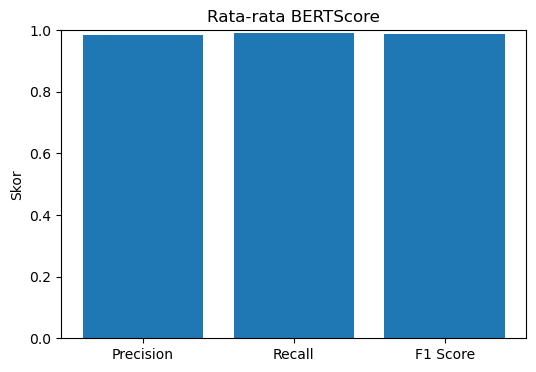

In [9]:
# (Opsional) Visualisasi sederhana rata-rata BERTScore
import matplotlib.pyplot as plt

mean_scores_series = df[["Precision", "Recall", "F1 Score"]].mean()
plt.figure(figsize=(6,4))
plt.bar(mean_scores_series.index, mean_scores_series.values)
plt.title("Rata-rata BERTScore")
plt.ylabel("Skor")
plt.ylim(0, 1.0)
plt.show()

In [ ]:
# Simpan ringkasan ke CSV (opsional)
output_summary_path = "ringkasan_bertscore.csv"
summary_stats.to_csv(output_summary_path, index=True)
output_summary_path